# Bayesian fundamentals: Beta-Binomial model
**Author:** T.V.Q (James) <br>
**Date:** May 27, 2026

## 1. Overview
This report aim to visualize the fundamentals of Beta-Binomial model and the simulation of one example. Narrative about the example is presented in my Notion page

In [1]:
# Load Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 2. Visualization of Beta-Binomial model
### 2.1. Beta prior distribution
Beta distribution is commonly used to model proportion or probability as it has great flexibility to reflect prior information
* The Beta distribution is defined over the interval [0,1] and is parameterized by two shape parameters, $\alpha$ and $\beta$, which dictate the distribution’s shape. <br>
* Suppose that for our parameter $\theta$ we have $\theta \sim Beta(\alpha, \beta)$ <br>
	=> The $PMF$ of the distribution of $\theta$ is given by:
$p(\theta) = \cfrac{\Gamma (\alpha+\beta) }{\Gamma (\alpha) \Gamma (\beta)} \times \theta^{\alpha-1} (1-\theta)^{\beta-1}$

* By modifying $\alpha$ and $\beta$, we can get various shapes of Beta distribution

**Visualization of Beta distribution of some $\alpha$ and $\beta$ pairs**

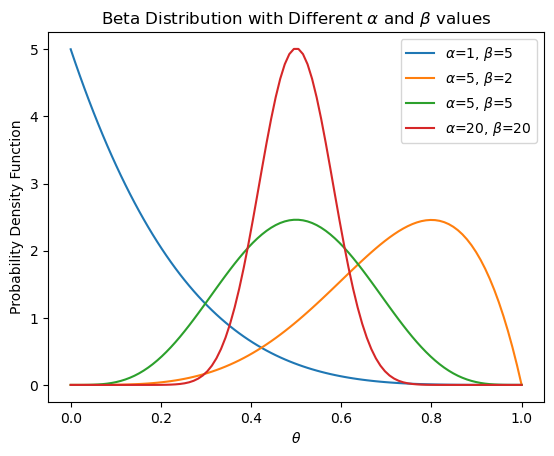

In [2]:
# Define alpha and beta pairs
alpha_beta_pairs = [(1, 5), (5, 2), (5, 5), (20, 20)]

# Set up the x-axis values
#		np.linspace() function creates an array of evenly spaced numbers over a specific interval
#			the interval is defined as [0,1]
#			the number of elements in the array is set at 100 (num=100)
#			by default both ends of the interval are included in the array

x = np.linspace(0, 1, num=100)

# Plot the distributions
#		plt.figure() function creates a new figure to add plots
plt.figure()

#		a loop to create a density plot for each pair of alpha and beta
for a, b in alpha_beta_pairs:
    y = stats.beta.pdf(x, a, b)
    plt.plot(x, y, label=rf"$\alpha$={a}, $\beta$={b}") # use raw f-string for latex symbol

#		customize the figure
plt.title(r"Beta Distribution with Different $\alpha$ and $\beta$ values")
plt.xlabel(r"$\theta$") # use raw string for latex symbol
plt.ylabel("Probability Density Function")
plt.legend()
plt.show()

### 2.2. Beta posterior distribution
To visualize the posterior distribution, we will use the example of election poll. <br>
In this example, we have a prior distribution $\theta \sim Beta(45,55)$ and a poll result of 15 supporters out of 50 voters

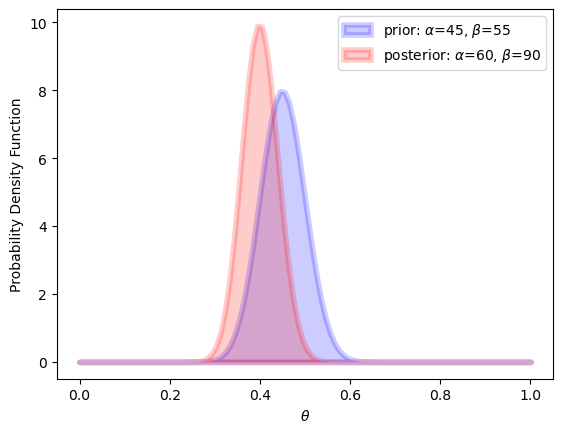

In [3]:
# Assign the values
a_prior = 45
b_prior = 55
n       = 50
y       = 15

# Set up the x-axis values
theta = np.linspace(0, 1, num=100)

# Setup prior distribution
prior = stats.beta.pdf(theta, a_prior, b_prior)

#	Derive the parameter of the posterior beta distribution
a_post = a_prior + y
b_post = b_prior + n - y

# Setup posterior distibution
post = stats.beta.pdf(theta, a_post, b_post)

# Plot the distributions
plt.figure()
plt.fill_between(theta, prior, lw=4, color="b", label=rf"prior: $\alpha$={a_prior}, $\beta$={b_prior}", alpha=0.2)
plt.fill_between(theta, post, lw=4, color="r", label=rf"posterior: $\alpha$={a_post}, $\beta$={b_post}", alpha=0.2)
plt.xlabel(r"$\theta$")
plt.ylabel("Probability Density Function")
plt.legend()


## 3. Example: election poll
Summary:
* You are running for president of the US. From previous poll, your chance that an individual voter would support you in a poll is: <br>
	$\theta \sim Beta(45,55)$
* Suppose you conduct a new poll including 50 random voters and find out that only 15 of them support you. <br>
	$y = 15$
* From this result, you can conclude that your support decreases. 

The analysis presented below demonstrate the simulation to visualize our finding.

In [4]:
# Set seed
#		np.random.default_rng() function sets the seed for all NumPy random functions

random_seed = 42
np.random.default_rng(random_seed)

Generator(PCG64) at 0x1E575FB67A0

### 3.1. Simulate the prior distribution
Simulate a prior distribution of 10,000 values

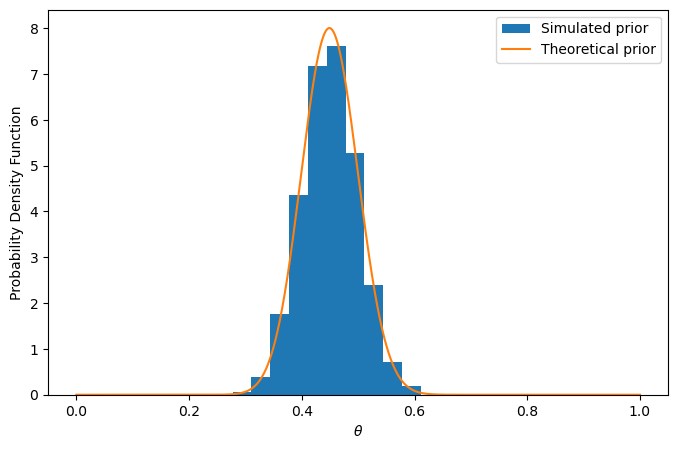

In [5]:
# Simulate 10,000 values from beta distribution
poll_sim_prior = np.random.beta(a=45, b=55, size=10000)

# Set up the theoretical beta distribution with 10,000 values
x_theore = np.linspace(0, 1, num=10000)
y_theore = stats.beta.pdf(x_theore, 45, 55)

# Plot the theoretical beta distribution and simulated distribution
plt.figure(figsize=(8, 5))
plt.hist(poll_sim_prior, density=True, label="Simulated prior")
plt.plot(x_theore, y_theore, label="Theoretical prior")
plt.xlabel(r"$\theta$")
plt.ylabel("Probability Density Function")
plt.legend()


The simulated prior distribution is roughly fitted with the theoretical $\theta \sim Beta(45,55)$

### 3.2. Simulate the posterior distribution

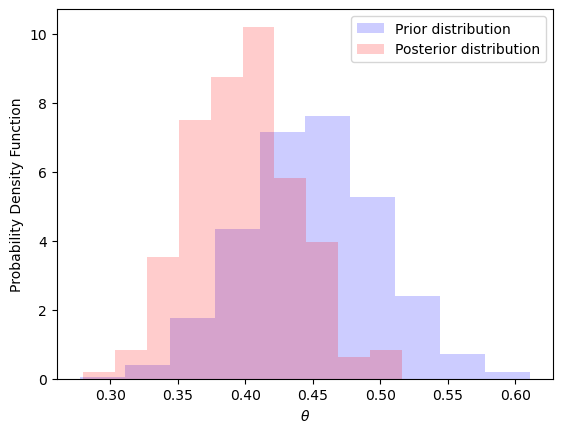

In [6]:
# Create a dataframe from prior distribution
poll_sim_joint = pd.DataFrame({"theta": poll_sim_prior})

# Simulate the number of successes for each value of theta in posterior distribution
poll_sim_joint["y"] = np.random.binomial(n=50, p=poll_sim_joint["theta"], size=10000)

# Filter out posterior distribution
poll_sim_post = poll_sim_joint[poll_sim_joint["y"] == 15]

# Plot the simulated prior and posterior distributions
plt.figure()
plt.hist(poll_sim_prior, density=True,
         label="Prior distribution", alpha=0.2, color="b")
plt.hist(poll_sim_post["theta"], density=True,
         label="Posterior distribution", alpha=0.2, color="r")
plt.xlabel(r"$\theta$")
plt.ylabel("Probability Density Function")
plt.legend()


The visualization of both distributions shows that after observing the new poll result, the belief about your support in a poll should be updated. The support decreases

In [7]:
%load_ext watermark
%watermark -n -u -v -iv

Last updated: Wed, 27 May 2026

Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.13.0

matplotlib: 3.10.9
numpy     : 2.4.6
pandas    : 3.0.3
scipy     : 1.17.1

